# Kentucky's 2025-26 Season Review

Kentucky entered the 2025-26 season ranked No. 4 in the preseason poll, backed by one of the top transfer portal classes in the country. A 22-14 finish and a 29th-place ranking in adjusted efficiency felt like a letdown given those expectations. But a deeper look at the numbers tells a more complicated story, one where the roster strategy mostly worked, and the gap between potential and result came down to two costly injuries.


In [4]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Kentucky colors
UK_BLUE = '#0033A0'
UK_WHITE = '#FFFFFF'
UK_GRAY = '#808080'

print("Ready to build")

Ready to build


## Section 1: By the Numbers

Kentucky ranked 28th nationally in adjusted defensive efficiency, allowing just 99.3 points per 100 possessions against a Division I average of 109.3, meaning they gave up roughly 10 fewer points per 100 possessions than a typical team. Note: for defensive efficiency, a lower number is better. Offensively, Kentucky ranked 40th nationally with a 120.4 adjusted efficiency, also well above the 109.3 average. Their four factors profile shows a team that shot efficiently (53.3 eFG%), took care of the ball (15.4 turnover rate), and rebounded well (33.2 offensive rebound rate), all better than the national average. By the underlying numbers, this was a top-30 caliber team on both ends of the floor.

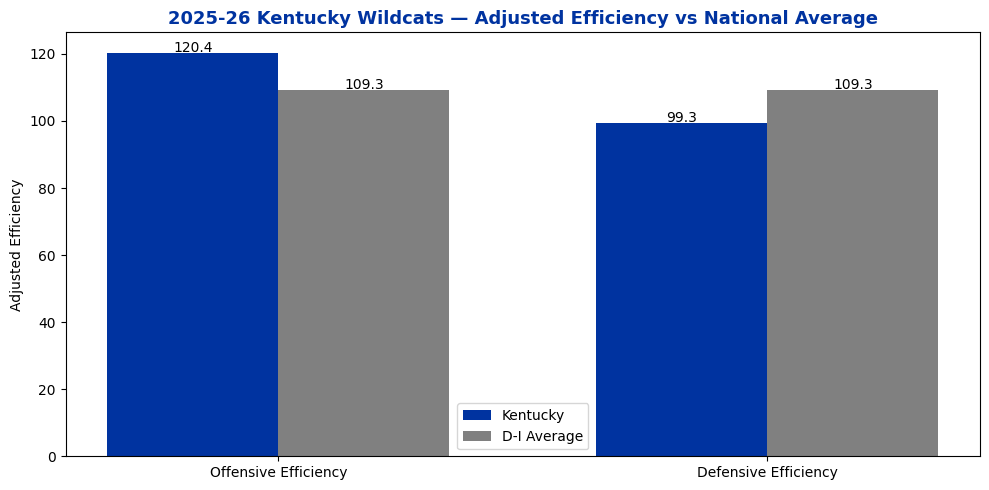

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(2)
width = 0.35

bars1 = ax.bar(x - width/2, df_team['kentucky'], width, label='Kentucky', color=UK_BLUE)
bars2 = ax.bar(x + width/2, df_team['national_avg'], width, label='D-I Average', color=UK_GRAY)

ax.set_title('2025-26 Kentucky Wildcats — Adjusted Efficiency vs National Average', 
             fontsize=13, fontweight='bold', color=UK_BLUE)
ax.set_xticks(x)
ax.set_xticklabels(['Offensive Efficiency', 'Defensive Efficiency'])
ax.set_ylabel('Adjusted Efficiency')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(bar.get_height()), ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(bar.get_height()), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('uk_efficiency_overview.png', dpi=150, bbox_inches='tight')
plt.show()

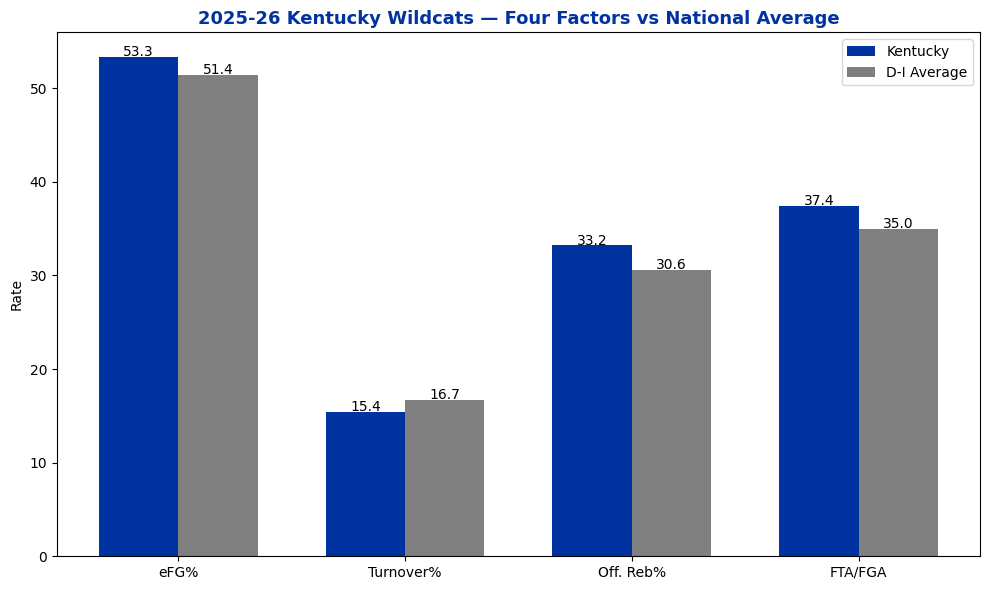

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(df_four['factor']))
width = 0.35

bars1 = ax.bar(x - width/2, df_four['kentucky_off'], width, label='Kentucky', color=UK_BLUE)
bars2 = ax.bar(x + width/2, df_four['national_avg'], width, label='D-I Average', color=UK_GRAY)

ax.set_title('2025-26 Kentucky Wildcats — Four Factors vs National Average',
             fontsize=13, fontweight='bold', color=UK_BLUE)
ax.set_xticks(x)
ax.set_xticklabels(df_four['factor'])
ax.set_ylabel('Rate')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(bar.get_height()), ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(bar.get_height()), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('uk_four_factors.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 2: The Transfer Class, Undermined by Injury
Kentucky boasted the 2nd ranked portal class in the country in 2025-26 according to 247 Sports. This class was highlighted by Jaland Lowe (Pittsburgh), Denzel Aberdeen (Florida), Kam Williams (Tulane), Mouhamed Dioubate (Alabama), and Jayden Quaintance (Arizona State), who arrived recovering from a previously torn ACL, and played for games before suffering another setback. The Jaland Lowe situation was also damaging, projected as the starting point guard, Lowe battled a recurring shoulder injury across mulitple instances that eventually led to a season ending surgery being announced on January 12th. This injury led to Lowe only playing in 9 games. Freshman Jasper Johnson emerged as a reliable contributor appearing in 35 games at 22.9% usage, the fourth highest on the roster, providing stability in the backcourt during Lowe's abscence. Excluding Lowe's injury-affected numbers, the transfer class averaged a 121.7 offensive rating and 58.8 true shooting percentage. Both the best marks of any player group on the roster. The data suggests the underperformance of the portal class relative to preseason expectations was driven largely by injuries, not by the quality of players Kentucky brought in. 

In [8]:
players = {
    'player': ['Otega Oweh', 'Jaland Lowe', 'Denzel Aberdeen', 'Jasper Johnson',
               'Malachi Moreno', 'Mo Dioubate', 'Brandon Garrison', 'Andrija Jelavic',
               'Collin Chandler', 'Kam Williams', 'Trent Noah'],
    'ortg': [111.2, 102.1, 118.7, 105.1, 121.9, 121.3, 111.2, 109.0, 120.9, 125.1, 117.3],
    'usage': [27.2, 25.2, 21.0, 22.9, 18.3, 19.6, 16.4, 18.1, 15.9, 14.0, 13.5],
    'ts_pct': [55.4, 45.1, 56.0, 53.4, 62.3, 58.8, 58.0, 54.6, 60.5, 61.7, 54.9],
    'games': [36, 9, 35, 35, 30, 10, 36, 32, 31, 24, 27],
    'transfer': ['Returning', 'New Transfer', 'New Transfer', 'Freshman',
                 'Freshman', 'New Transfer', 'Returning', 'International',
                 'Returning', 'New Transfer', 'Returning']
}

df_players = pd.DataFrame(players)
print(df_players[['player', 'ortg', 'usage', 'ts_pct', 'transfer']])

              player   ortg  usage  ts_pct       transfer
0         Otega Oweh  111.2   27.2    55.4      Returning
1        Jaland Lowe  102.1   25.2    45.1   New Transfer
2    Denzel Aberdeen  118.7   21.0    56.0   New Transfer
3     Jasper Johnson  105.1   22.9    53.4       Freshman
4     Malachi Moreno  121.9   18.3    62.3       Freshman
5        Mo Dioubate  121.3   19.6    58.8   New Transfer
6   Brandon Garrison  111.2   16.4    58.0      Returning
7    Andrija Jelavic  109.0   18.1    54.6  International
8    Collin Chandler  120.9   15.9    60.5      Returning
9       Kam Williams  125.1   14.0    61.7   New Transfer
10        Trent Noah  117.3   13.5    54.9      Returning


In [10]:
summary = df_players.groupby('transfer')[['ortg', 'usage', 'ts_pct']].mean().round(1)
print(summary)

                ortg  usage  ts_pct
transfer                           
Freshman       113.5   20.6    57.8
International  109.0   18.1    54.6
New Transfer   116.8   20.0    55.4
Returning      115.2   18.2    57.2


In [11]:
no_lowe = df_players[df_players['player'] != 'Jaland Lowe']
summary2 = no_lowe.groupby('transfer')[['ortg', 'usage', 'ts_pct',]].mean().round(1)
print("Without Lowe")
print(summary2)

Without Lowe
                ortg  usage  ts_pct
transfer                           
Freshman       113.5   20.6    57.8
International  109.0   18.1    54.6
New Transfer   121.7   18.2    58.8
Returning      115.2   18.2    57.2


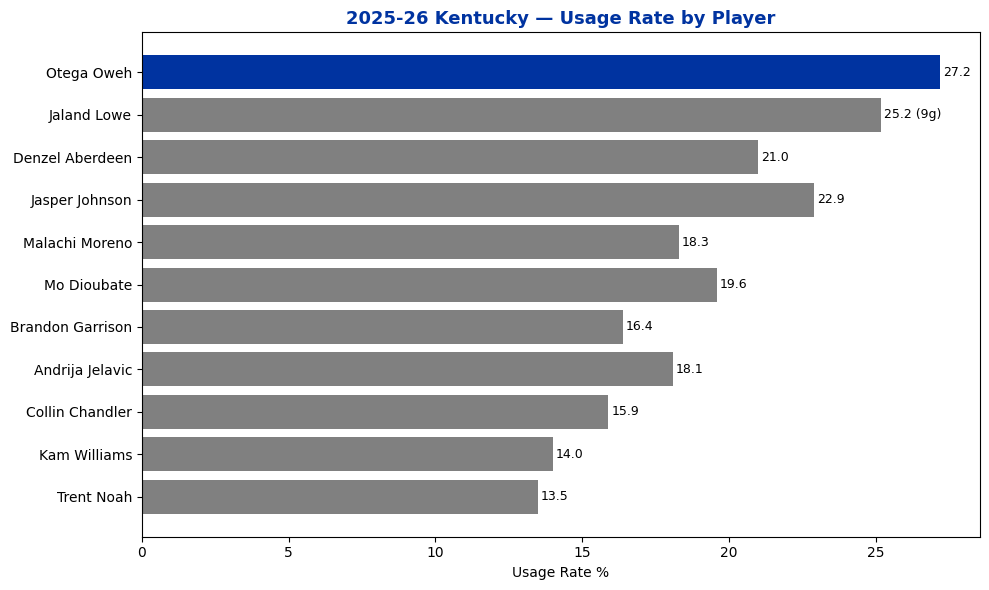

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

colors_list = [UK_BLUE if p == 'Otega Oweh' else UK_GRAY for p in df_players['player']]

bars = ax.barh(df_players['player'], df_players['usage'], color=colors_list)
ax.set_title('2025-26 Kentucky — Usage Rate by Player',
             fontsize=13, fontweight='bold', color=UK_BLUE)
ax.set_xlabel('Usage Rate %')
ax.invert_yaxis()

for bar, val, player, games in zip(bars, df_players['usage'], df_players['player'], df_players['games']):
    label = f"{val} ({games}g)" if player == 'Jaland Lowe' else str(val)
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=9)

plt.tight_layout()
plt.savefig('uk_usage.png', dpi=150, bbox_inches='tight')
plt.show()

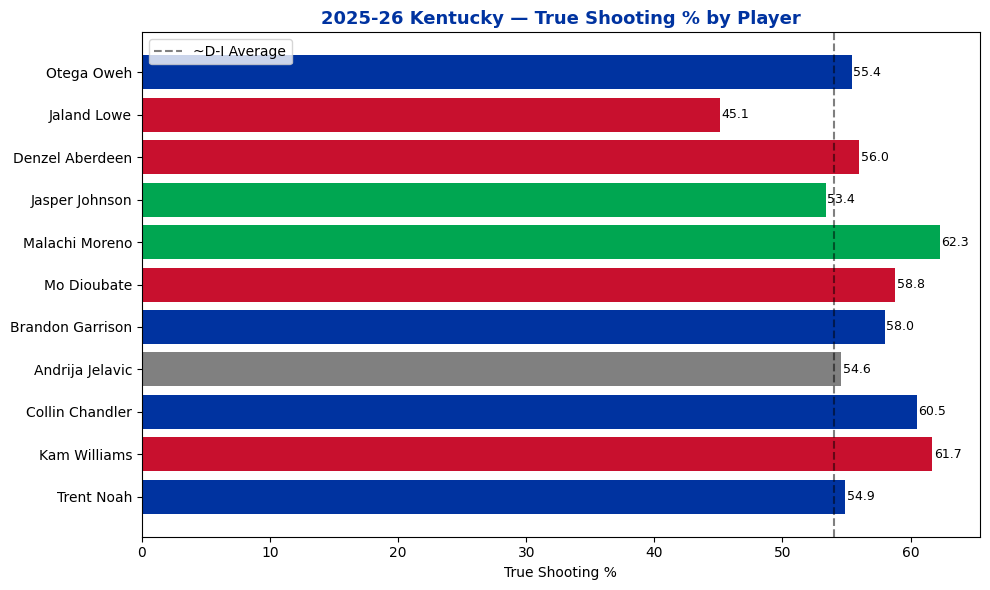

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

colors_list = []
for t in df_players['transfer']:
    if t == 'Returning':
        colors_list.append(UK_BLUE)
    elif t == 'New Transfer':
        colors_list.append('#C8102E')
    elif t == 'Freshman':
        colors_list.append('#00A651')
    else:
        colors_list.append(UK_GRAY)

bars = ax.barh(df_players['player'], df_players['ts_pct'], color=colors_list)
ax.axvline(x=54.0, color='black', linestyle='--', alpha=0.5, label='~D-I Average')
ax.set_title('2025-26 Kentucky — True Shooting % by Player',
             fontsize=13, fontweight='bold', color=UK_BLUE)
ax.set_xlabel('True Shooting %')
ax.invert_yaxis()
ax.legend()

for bar, val in zip(bars, df_players['ts_pct']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('uk_ts_pct.png', dpi=150, bbox_inches='tight')
plt.show()

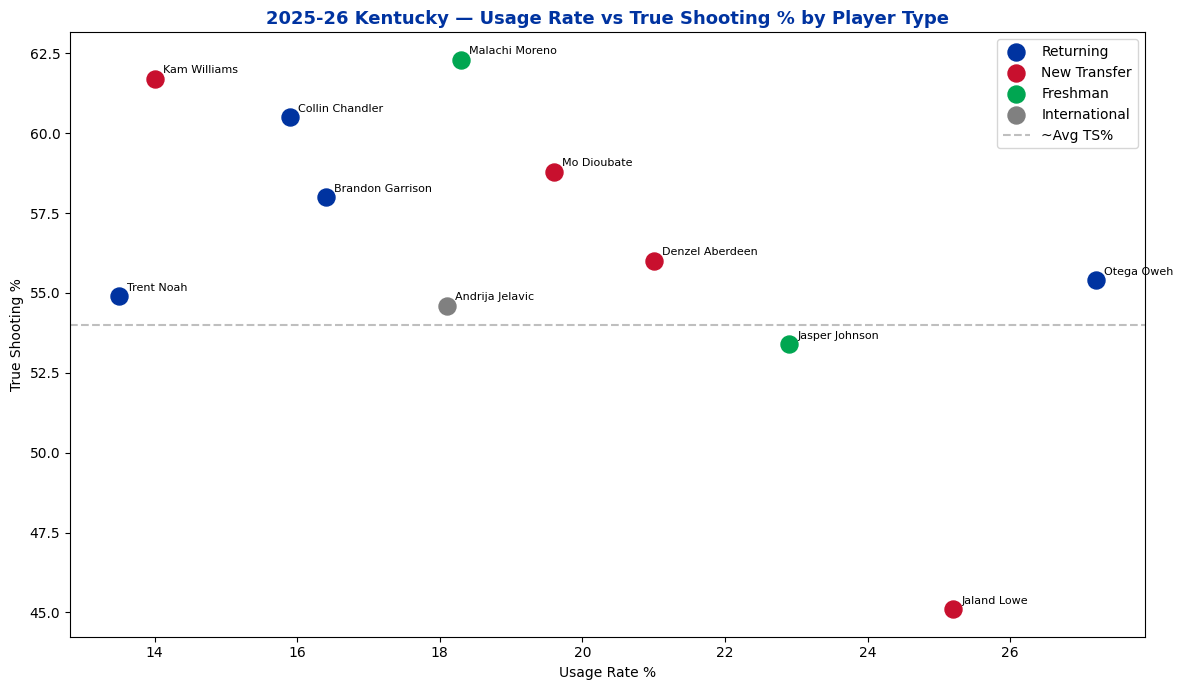

In [9]:
colors = {
    'Returning': UK_BLUE,
    'New Transfer': '#C8102E',
    'Freshman': '#00A651',
    'International': UK_GRAY
}

fig, ax = plt.subplots(figsize=(12, 7))

for ptype in colors:
    mask = df_players['transfer'] == ptype
    ax.scatter(df_players[mask]['usage'], df_players[mask]['ts_pct'],
               c=colors[ptype], s=150, label=ptype, zorder=5)
    for _, row in df_players[mask].iterrows():
        ax.annotate(row['player'], (row['usage'], row['ts_pct']),
                    textcoords='offset points', xytext=(6, 4), fontsize=8)

ax.axhline(y=54.0, color='gray', linestyle='--', alpha=0.5, label='~Avg TS%')
ax.set_title('2025-26 Kentucky — Usage Rate vs True Shooting % by Player Type',
             fontsize=13, fontweight='bold', color=UK_BLUE)
ax.set_xlabel('Usage Rate %')
ax.set_ylabel('True Shooting %')
ax.legend()
plt.tight_layout()
plt.savefig('uk_player_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

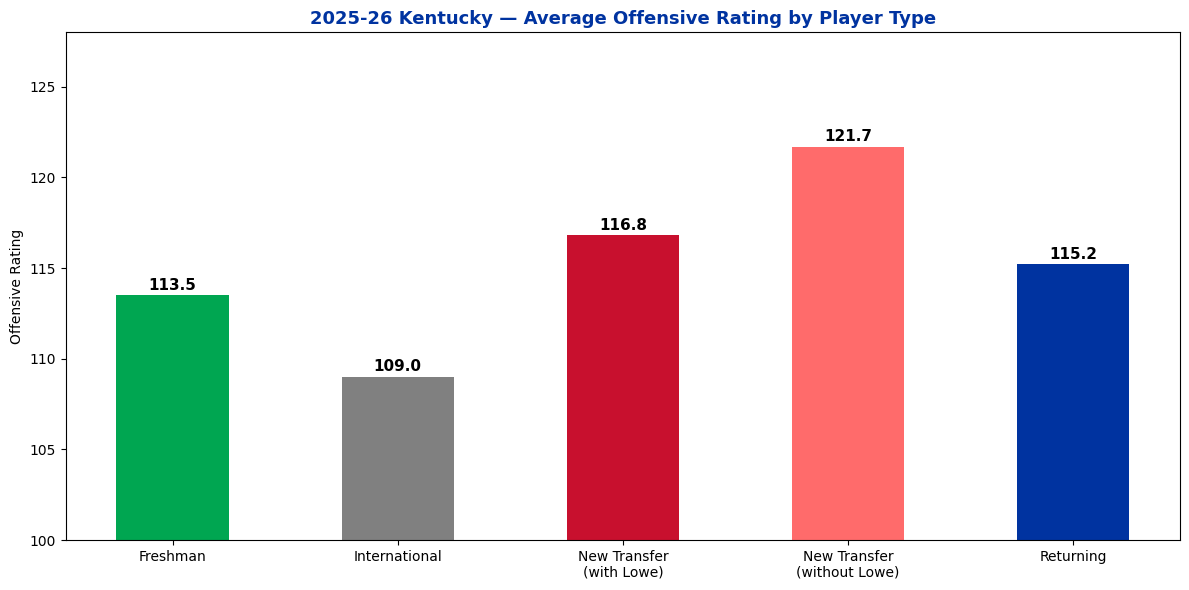

In [12]:
labels = ['Freshman', 'International', 'New Transfer\n(with Lowe)', 'New Transfer\n(without Lowe)', 'Returning']
ortg_vals = [113.5, 109.0, 116.8, 121.7, 115.2]
colors_list = ['#00A651', UK_GRAY, '#C8102E', '#FF6B6B', UK_BLUE]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(labels, ortg_vals, color=colors_list, width=0.5)
ax.set_title('2025-26 Kentucky — Average Offensive Rating by Player Type',
             fontsize=13, fontweight='bold', color=UK_BLUE)
ax.set_ylabel('Offensive Rating')
ax.set_ylim(100, 128)
for bar, val in zip(bars, ortg_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('uk_transfer_impact.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
split_data = {
    'period': ['With Lowe (9 games)', 'Without Lowe (27 games)'],
    'wins': [5, 17],
    'losses': [4, 10],
    'win_pct': [0.556, 0.630]
}

df_split = pd.DataFrame(split_data)
print(df_split)

                    period  wins  losses  win_pct
0      With Lowe (9 games)     5       4    0.556
1  Without Lowe (27 games)    17      10    0.630


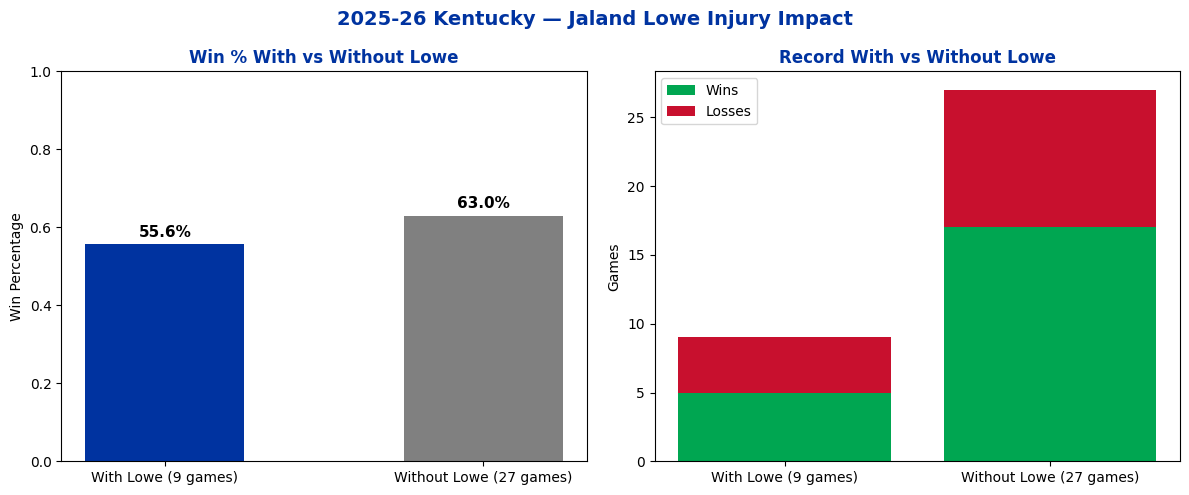

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Win percentage chart
axes[0].bar(df_split['period'], df_split['win_pct'], 
            color=[UK_BLUE, UK_GRAY], width=0.5)
axes[0].set_title('Win % With vs Without Lowe', fontweight='bold', color=UK_BLUE)
axes[0].set_ylabel('Win Percentage')
axes[0].set_ylim(0, 1)
for i, val in enumerate(df_split['win_pct']):
    axes[0].text(i, val + 0.02, f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

# Games breakdown
axes[1].bar(df_split['period'], df_split['wins'], color='#00A651', label='Wins')
axes[1].bar(df_split['period'], df_split['losses'], bottom=df_split['wins'], 
            color='#C8102E', label='Losses')
axes[1].set_title('Record With vs Without Lowe', fontweight='bold', color=UK_BLUE)
axes[1].set_ylabel('Games')
axes[1].legend()

fig.suptitle('2025-26 Kentucky — Jaland Lowe Injury Impact', 
             fontsize=14, fontweight='bold', color=UK_BLUE)
plt.tight_layout()
plt.savefig('uk_lowe_impact.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
play_types = {
    'play_type': ['Spot Up', 'Transition', 'P&R Ball Handler', 'Cut',
                  'Off. Rebounds', 'Isolation', 'Post Up', 'Handoffs',
                  'P&R Roll Man', 'Off Screen'],
    'possessions': [659, 514, 492, 214, 185, 165, 140, 128, 126, 104],
    'ppp': [0.945, 1.255, 0.789, 1.318, 1.216, 0.915, 0.921, 1.180, 0.968, 0.846],
    'ppp_rank': [38, 98, 39, 86, 84, 77, 62, 99, 30, 25],
    'rating': ['Average', 'Excellent', 'Average', 'Excellent',
               'Excellent', 'Very Good', 'Good', 'Excellent',
               'Below Average', 'Below Average']
}

df_plays = pd.DataFrame(play_types)
df_plays = df_plays.rename(columns={'ppp': 'points_per_play', 'ppp_rank': 'ppp_rank'})
print(df_plays[['play_type', 'possessions', 'points_per_play', 'ppp_rank', 'rating']])

          play_type  possessions  points_per_play  ppp_rank         rating
0           Spot Up          659            0.945        38        Average
1        Transition          514            1.255        98      Excellent
2  P&R Ball Handler          492            0.789        39        Average
3               Cut          214            1.318        86      Excellent
4     Off. Rebounds          185            1.216        84      Excellent
5         Isolation          165            0.915        77      Very Good
6           Post Up          140            0.921        62           Good
7          Handoffs          128            1.180        99      Excellent
8      P&R Roll Man          126            0.968        30  Below Average
9        Off Screen          104            0.846        25  Below Average


## Section 3: Where Kentucky Won and Lost Possessions

Play type data from Synergy Sports can give us a good feel on where Kentucky's offense thrived and where it struggled. Note: Synergy measures PPP as points per play rather than points per possesion, a new play is counted after each offensive rebound. Meaning one possesion can include multiple plays. With that in mind, Kentucky's transition offense ranked in the 98th percentile nationally at 1.255 PPP, their cutting game was equally as effective 1.318 PPP (86th Percentile). An area Kentucky struggled was their pick and roll ball handler efficiency. At just 0.789 PPP (39th Percentile). This also happened to be their third most used play type. This directly connects with the Lowe injury. A healthy point guard who was a corner stone of the 2nd best portal class in the country would have imporved this number considerably. 

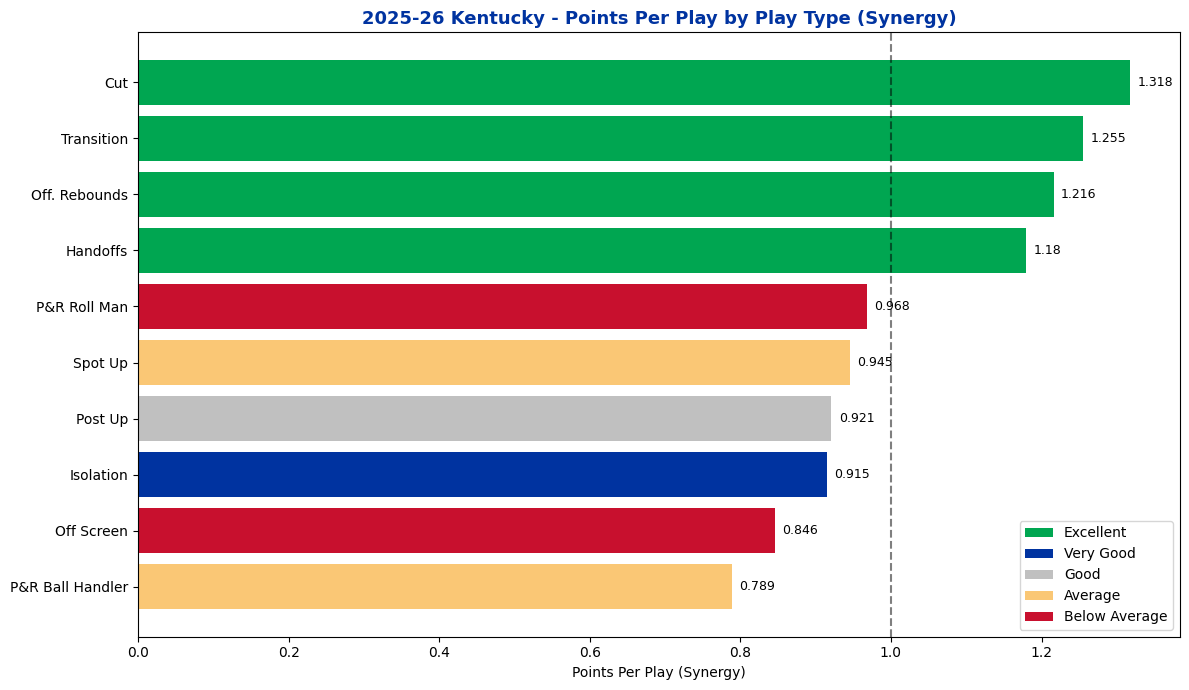

In [19]:
colors_rating = {
    'Excellent': '#00A651',
    'Very Good': '#0033A0',
    'Good': '#C0C0C0', 
    'Average': '#FAC775', 
    'Below Average': '#C8102E',
}
df_plays_sorted = df_plays.sort_values('points_per_play', ascending=True)
bar_colors = [colors_rating[r] for r in df_plays_sorted['rating']]

fig, ax = plt.subplots(figsize=(12,7))
bars = ax.barh(df_plays_sorted['play_type'], df_plays_sorted['points_per_play'],
               color=bar_colors)
ax.axvline(x=1.0, color='black', linestyle='--', alpha=0.5, label='1.0 PPP Benchmark')
ax.set_title('2025-26 Kentucky - Points Per Play by Play Type (Synergy)',
             fontsize=13, fontweight='bold', color=UK_BLUE)
ax.set_xlabel('Points Per Play (Synergy)')
for bar, val in zip(bars, df_plays_sorted['points_per_play']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors_rating[r], label=r)
                   for r in ['Excellent', 'Very Good', 'Good', 'Average', 'Below Average', ]]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('uk_play_types.png', dpi=150, bbox_inches='tight')
plt.show()



## Section 4: Looking Ahead — Kentucky's 2026-27 Transfer Class

The 2026-27 portal class for Kentucky is another exciting one. The additions of Milan Momcilovic (Iowa State) and Zoom Diallo (Washington) address the two biggest weaknesses identified in Section 3. Milan Momcilovic posted a 136.9 offensive rating and a 69.3 true shooting percentage last season. Both are top 10 marks nationally, and projects as a direct solution to Kentucky's below-average spot-up shooting (38th percentile in 2025-26). Diallo brings a 30.3 assist rate to help solve the pick and roll ineffciency that plauged Kentucky without a healthy Jaland Lowe. The remaining additions include Alex Wilkins (Furman), Justin McBride (James Madison), Jerone Morton (Washington St.), and Franck Kepnang (Washington), who all profile as solid SEC level contributors. International addition Ousmane N'Diaye (Senegal) adds front-court depth. Kentucky also returns a likely first round pick in this upcoming NBA Draft, Malachi Moreno, who brings back an elite post presence for the Wildcats. Kam Williams and Trent Noah are also back, giving the program continuty at key postions. 

In [20]:
incoming = {
    'player': ['Milan Momcilovic', 'Zoom Diallo', 'Alex Wilkins',
               'Justin McBride', 'Jerone Morton', 'Frank Kepnang',] ,
    'prev_school':[ 'Iowa State', 'Washington', 'Furman', 
                    'James Madison', 'Washington State', 'Washington'],
    'ortg': [136.9, 112.5, 103.9, 113.6, 116.3, 110.5],
    'usage': [18.2, 28.3, 34.3, 27.0, 17.1, 15.3],
    'ts_pct': [69.3, 56.3, 56.5, 59.1, 56.8, 54.4], 
    'position': ['PF', 'PG', 'CG', 'PF', 'PG', 'C']
}
df_incoming = pd.DataFrame(incoming)
print(df_incoming)

             player       prev_school   ortg  usage  ts_pct position
0  Milan Momcilovic        Iowa State  136.9   18.2    69.3       PF
1       Zoom Diallo        Washington  112.5   28.3    56.3       PG
2      Alex Wilkins            Furman  103.9   34.3    56.5       CG
3    Justin McBride     James Madison  113.6   27.0    59.1       PF
4     Jerone Morton  Washington State  116.3   17.1    56.8       PG
5     Frank Kepnang        Washington  110.5   15.3    54.4        C


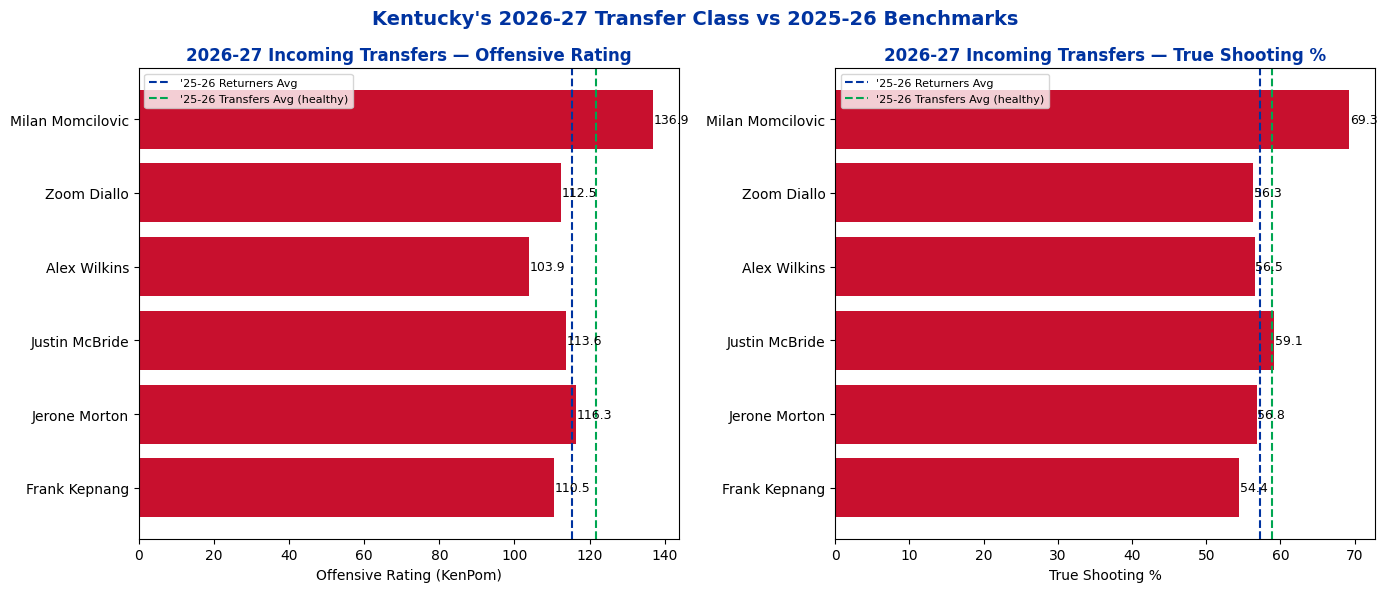

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 - ORtg comparison
axes[0].barh(df_incoming['player'], df_incoming['ortg'], color='#C8102E')
axes[0].axvline(x=115.2, color=UK_BLUE, linestyle='--', label="'25-26 Returners Avg")
axes[0].axvline(x=121.7, color='#00A651', linestyle='--', label="'25-26 Transfers Avg (healthy)")
axes[0].set_title('2026-27 Incoming Transfers — Offensive Rating', 
                   fontweight='bold', color=UK_BLUE)
axes[0].set_xlabel('Offensive Rating (KenPom)')
axes[0].invert_yaxis()
axes[0].legend(fontsize=8)

for i, val in enumerate(df_incoming['ortg']):
    axes[0].text(val + 0.2, i, str(val), va='center', fontsize=9)

# Chart 2 - TS% comparison
axes[1].barh(df_incoming['player'], df_incoming['ts_pct'], color='#C8102E')
axes[1].axvline(x=57.2, color=UK_BLUE, linestyle='--', label="'25-26 Returners Avg")
axes[1].axvline(x=58.8, color='#00A651', linestyle='--', label="'25-26 Transfers Avg (healthy)")
axes[1].set_title('2026-27 Incoming Transfers — True Shooting %',
                   fontweight='bold', color=UK_BLUE)
axes[1].set_xlabel('True Shooting %')
axes[1].invert_yaxis()
axes[1].legend(fontsize=8)

for i, val in enumerate(df_incoming['ts_pct']):
    axes[1].text(val + 0.1, i, str(val), va='center', fontsize=9)

fig.suptitle("Kentucky's 2026-27 Transfer Class vs 2025-26 Benchmarks",
             fontsize=14, fontweight='bold', color=UK_BLUE)
plt.tight_layout()
plt.savefig('uk_incoming_transfers.png', dpi=150, bbox_inches='tight')
plt.show()

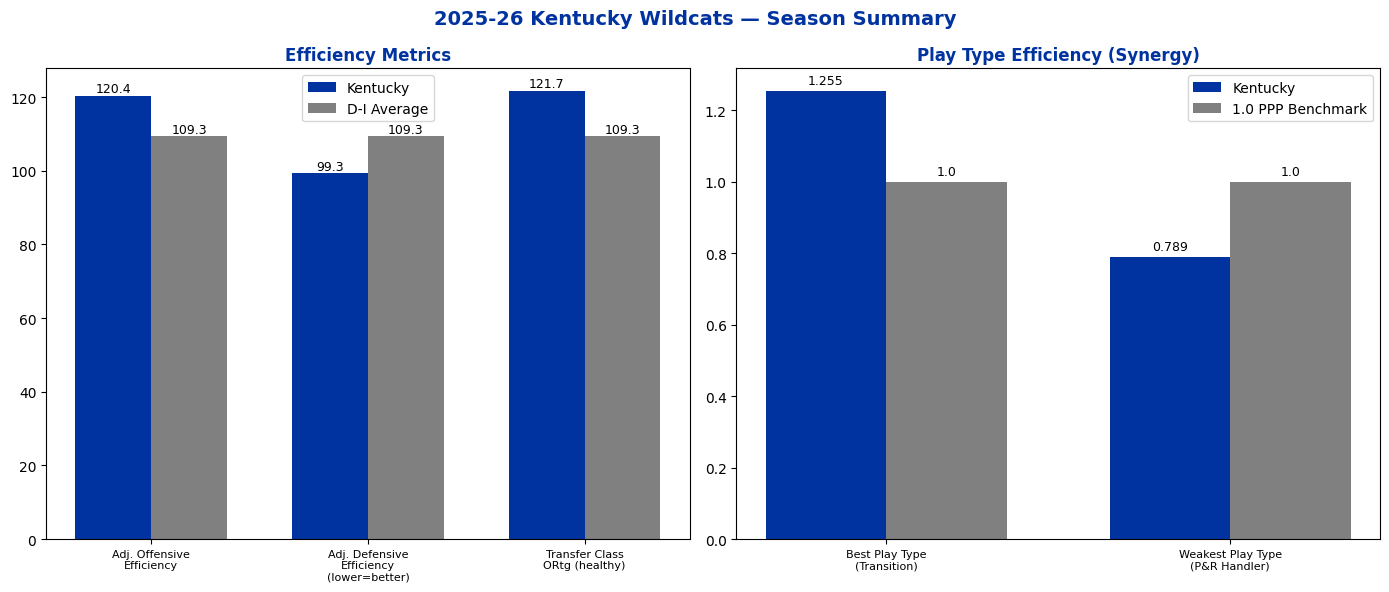

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Efficiency metrics - using real numbers, no inversion
eff_categories = ['Adj. Offensive\nEfficiency', 'Adj. Defensive\nEfficiency\n(lower=better)', 'Transfer Class\nORtg (healthy)']
eff_kentucky = [120.4, 99.3, 121.7]
eff_avg = [109.3, 109.3, 109.3]

x1 = np.arange(len(eff_categories))
width = 0.35

axes[0].bar(x1 - width/2, eff_kentucky, width, label='Kentucky', color=UK_BLUE)
axes[0].bar(x1 + width/2, eff_avg, width, label='D-I Average', color=UK_GRAY)
axes[0].set_title('Efficiency Metrics', fontweight='bold', color=UK_BLUE)
axes[0].set_xticks(x1)
axes[0].set_xticklabels(eff_categories, fontsize=8)
axes[0].legend()
for i, val in enumerate(eff_kentucky):
    axes[0].text(i - width/2, val + 1, str(val), ha='center', fontsize=9)
for i, val in enumerate(eff_avg):
    axes[0].text(i + width/2, val + 1, str(val), ha='center', fontsize=9)

# Play type metrics
play_categories = ['Best Play Type\n(Transition)', 'Weakest Play Type\n(P&R Handler)']
play_kentucky = [1.255, 0.789]
play_avg = [1.000, 1.000]

x2 = np.arange(len(play_categories))

axes[1].bar(x2 - width/2, play_kentucky, width, label='Kentucky', color=UK_BLUE)
axes[1].bar(x2 + width/2, play_avg, width, label='1.0 PPP Benchmark', color=UK_GRAY)
axes[1].set_title('Play Type Efficiency (Synergy)', fontweight='bold', color=UK_BLUE)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(play_categories, fontsize=8)
axes[1].legend()
for i, val in enumerate(play_kentucky):
    axes[1].text(i - width/2, val + 0.02, str(val), ha='center', fontsize=9)
for i, val in enumerate(play_avg):
    axes[1].text(i + width/2, val + 0.02, str(val), ha='center', fontsize=9)

fig.suptitle('2025-26 Kentucky Wildcats — Season Summary', fontsize=14, fontweight='bold', color=UK_BLUE)
plt.tight_layout()
plt.savefig('uk_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## Closing Note
A 22-14 record doesn't tell the full story of Kentucky's 2025-26 season. The underlying effciency numbers, the quality of transfer portal additions, and the defensive identity were all trending in the right direction. Two key injuries plauged Kentucky's season especially the one to Lowe. The 2026-27 roster brings new pieces headlined by Milan Momcilovic and Zoom Diallo that directly address the offensive weaknesses this analysis identified. Whether that translates to results remains to be seen, but the data suggests the program is moving in the right direction. 


**Data Sources**
- KenPom (kenpom.com) — adjusted efficiency ratings, four factors, and individual player metrics
- Synergy Sports — play type data (points per play)
- Sports Reference (sports-reference.com/cbb) — game log data
- 2026-27 roster and transfer portal information sourced from publicly available reporting as of June 2026